In [2]:
import pandas as pd
import numpy as np
import utility.my_utils as deniz
import matplotlib.pyplot as plt
import gc
import os
import mne


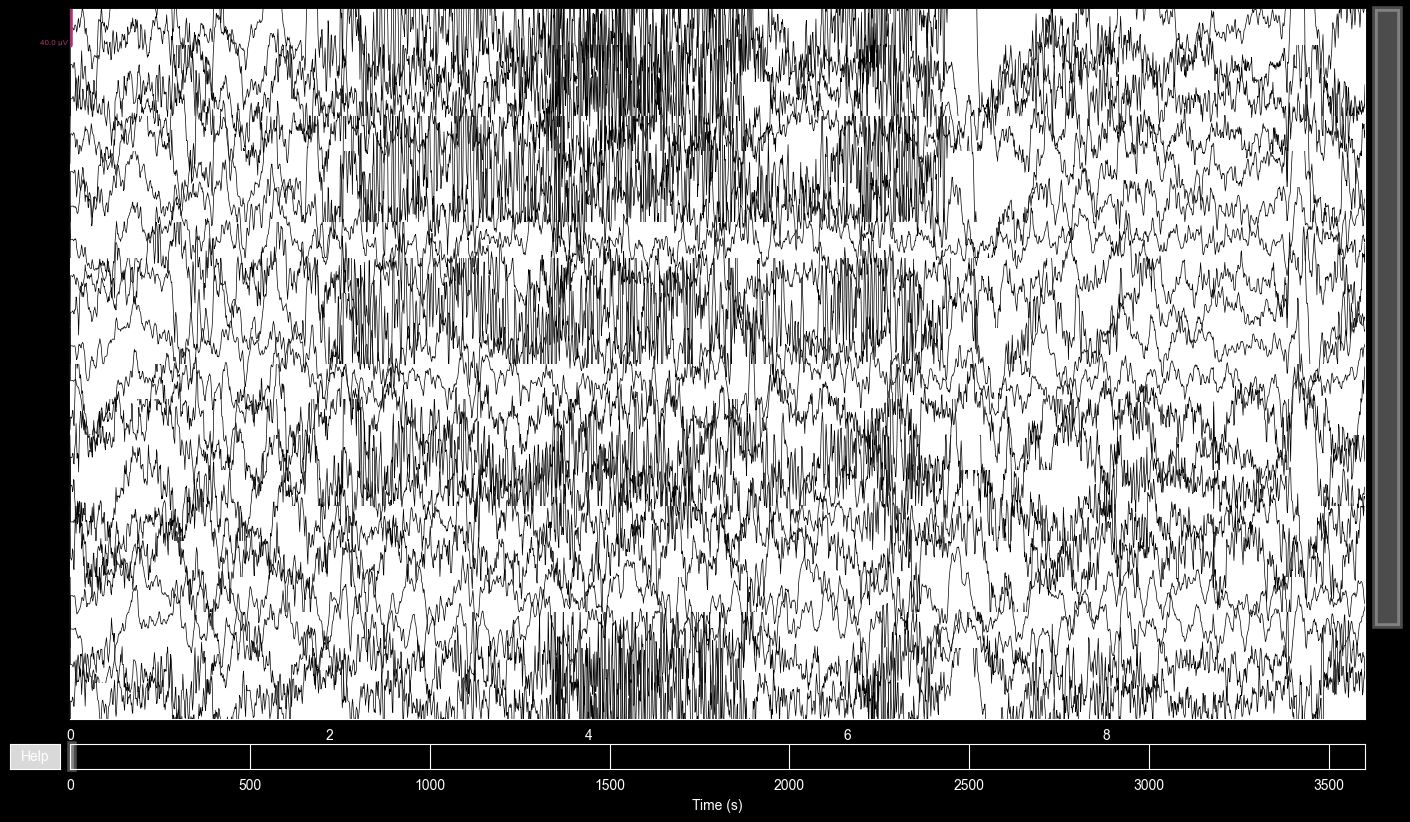

In [3]:
dataset_path = 'data-understanding/data/chb-mit'
raw_folders= deniz.get_folder_names(dataset_path)
raw_paths =deniz.get_edf_paths(dataset_path, raw_folders)
print(raw_paths[0])

raw = mne.io.read_raw_edf(raw_paths[0], preload=False, verbose=False)
raw.plot()


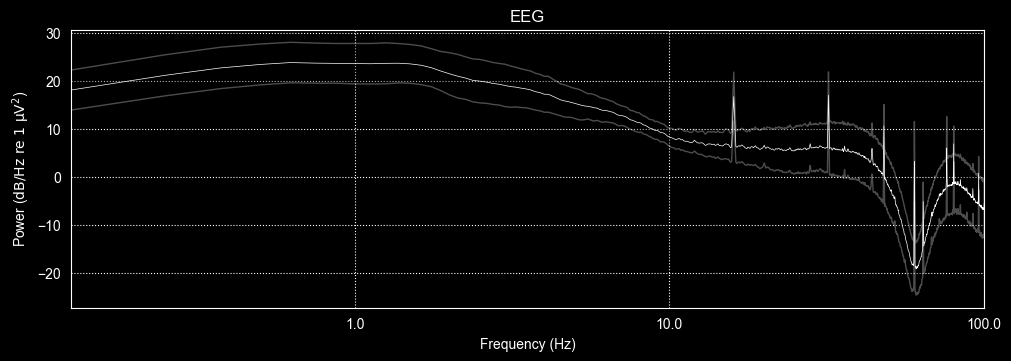

In [4]:
# 1. Compute PSD
spectrum = raw.compute_psd(fmax=100)

# Use the dark_background style context for visibility
with plt.style.context('dark_background'):

    # 2. Plot without averaging (Spatial colors)
    fig1 = spectrum.plot(
        average=False,
        picks="data",
        exclude="bads",
        amplitude=False,
        spatial_colors=True
    )
    # Force figure facecolor to match if it doesn't automatically
    fig1.patch.set_facecolor('white')

    # 3. Plot with averaging and log scale
    fig2 = spectrum.plot(
        average=True,
        xscale="log",
        amplitude=False
    )
    if hasattr(fig2.axes[0], 'get_lines'):
        for line in fig2.axes[0].get_lines():
            line.set_color('white')  # Make the main signal line white

    plt.show()

# After preprocessing

In [5]:
data_path = 'dataset_final/train'
deniz.verify_processed_data(data_path)

❌ Klasörde .npz dosyası bulunamadı!


In [6]:
file_path = "dataset_final/train/chb02/chb02_16_train.npz"

if os.path.exists(file_path):
    # Load the compressed numpy file
    sample = np.load(file_path)
    X = sample['X']  # EEG Signal
    y = sample['y']  # Label

    print("=" * 40)
    print(f" File Analysis: {os.path.basename(file_path)}")
    print("=" * 40)

    # Display Dimensions
    print(f"🔹 Signal Shape (Channels, Time): {X.shape}")
    print(f"🔹 Class Label: {y}")

    # Logic Check
    # 2 seconds * 128 Hz = 256 samples
    expected_shape = (18, 256)

    if X.shape == expected_shape:
        print(" Dimensions are correct (18 channels, 256 time points).")
    else:
        print(f"️ Unexpected dimensions! Expected {expected_shape}, got {X.shape}")
else:
    print(f" File not found: {file_path}")

if os.path.exists(file_path):
    # Load the compressed numpy file
    sample = np.load(file_path)
    X = npz['X']  # EEG Signal
    y = npz['y']  # Label

    print("=" * 40)
    print(f" File Analysis: {os.path.basename(file_path)}")
    print("=" * 40)

    # Display Dimensions
    print(f"🔹 Signal Shape (Channels, Time): {X.shape}")
    print(f"🔹 Class Label: {y}")

    # Logic Check
    # 2 seconds * 128 Hz = 256 samples
    expected_shape = (18, 256)

    if X.shape == expected_shape:
        print(" Dimensions are correct (18 channels, 256 time points).")
    else:
        print(f"️ Unexpected dimensions! Expected {expected_shape}, got {X.shape}")
else:
    print(f" File not found: {file_path}")

 File Analysis: chb02_16_train.npz
🔹 Signal Shape (Channels, Time): (230, 18, 256)
🔹 Class Label: [0 1 1 0 1 0 1 0 0 0 0 1 1 0 0 0 0 1 0 0 1 0 0 0 0 1 0 1 1 1 0 1 0 1 1 0 0
 0 1 0 1 0 0 1 1 1 0 1 0 1 0 1 0 1 1 1 0 0 1 1 1 0 0 1 0 1 0 1 1 1 1 1 0 0
 1 0 0 0 1 1 1 1 1 0 0 0 1 0 0 1 1 1 0 1 0 1 0 0 0 1 1 1 1 1 1 0 0 1 1 0 0
 1 1 0 1 1 0 0 1 1 0 0 1 1 0 0 0 0 1 0 1 0 1 0 0 0 1 0 1 1 0 1 0 1 0 0 1 1
 0 1 1 0 1 0 0 1 1 1 0 0 0 0 1 1 1 1 1 1 1 0 0 1 1 1 1 0 0 1 0 1 0 0 0 0 1
 1 1 1 0 0 0 0 0 0 1 1 1 1 1 0 0 0 0 0 1 0 0 1 1 0 0 0 1 1 0 1 0 1 0 0 0 0
 1 0 1 1 1 1 0 1]
️ Unexpected dimensions! Expected (18, 256), got (230, 18, 256)


In [7]:
print(X)

[[[ 2.55589403e-05  1.22799954e-05  7.43215582e-06 ... -5.89328285e-05
   -5.81022957e-05 -5.98353462e-05]
  [-1.72041479e-05 -8.79087690e-06  1.29155534e-05 ...  1.01518633e-05
    8.34651298e-07 -1.27917152e-05]
  [-2.20799918e-05 -5.11689220e-05 -9.24341685e-05 ...  6.12058998e-05
    4.93767081e-05  4.90131935e-05]
  ...
  [ 2.42641364e-05  4.68420737e-05  1.59637220e-04 ... -4.87604944e-05
   -2.40228985e-05 -7.21882568e-06]
  [ 9.48116387e-06  1.47213757e-05  1.42287640e-05 ...  3.62078489e-05
    2.47463849e-05  2.37366815e-05]
  [-6.29809542e-05 -6.24134210e-05 -5.55366216e-05 ...  2.72894412e-05
    2.22090589e-05  1.77068892e-05]]

 [[ 1.05329599e-04  8.37422919e-05  3.18428443e-05 ...  2.74208190e-05
    2.12693760e-05 -1.48041371e-05]
  [-1.05614125e-04 -1.38839253e-04 -1.40105025e-04 ...  1.40632275e-04
    1.49720172e-04  1.56965499e-04]
  [ 1.26785519e-05  4.81262461e-05  8.87422447e-05 ... -3.35427993e-05
   -1.84584688e-05 -1.17094512e-05]
  ...
  [-2.23181930e-05 -2.0

In [8]:
print(set(y))

{np.int8(0), np.int8(1)}


In [15]:
# Use os.path.join to handle the folder correctly
file_path = os.path.join("dataset_final/train/chb10", "chb10_27.npz")

print(f"Loading file from: {file_path}")

try:
    # Load the .npz file
    preprocessed_data = np.load(file_path, allow_pickle=True)

    # 1. Extract the actual data array
    print(f"Keys in file: {preprocessed_data.files}")
    eeg_data = preprocessed_data[preprocessed_data.files[0]]

    print(f"Original Shape: {eeg_data.shape}")
    # Likely (1800, 18, 256) -> (Epochs, Channels, Time)

    # 2. FIX: Convert 3D Epochs to 2D Continuous Data
    if eeg_data.ndim == 3:
        print(" Detected 3D Epoch data. Reshaping to 2D continuous...")

        # Step A: Move Channels to the first dimension
        # Current: (Epochs, Channels, Time) -> Target: (Channels, Epochs, Time)
        eeg_data = np.transpose(eeg_data, (1, 0, 2))

        # Step B: Flatten Epochs and Time into one continuous time dimension
        # Shape becomes: (Channels, Epochs * Time)
        n_channels = eeg_data.shape[0]
        eeg_data = eeg_data.reshape(n_channels, -1)

        print(f" New 2D Shape: {eeg_data.shape}")

    # 3. Define Metadata manually
    sfreq = 128.0  # Assuming 128Hz
    ch_names = [   # Standard CHB-MIT 18 channels
        'FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1',
        'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1',
        'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2',
        'FP2-F8', 'F8-T8', 'T8-P8', 'P8-O2',
        'FZ-CZ', 'CZ-PZ'
    ]

    # Create MNE info object
    info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types='eeg')

    # Create RawArray object (Now receives correct 2D data)
    raw = mne.io.RawArray(eeg_data, info)

    # --- PLOTTING SECTION ---

    # Reset any previous style to default (White)
    plt.style.use('default')

    # 1. Plot Raw Traces
    fig_raw = raw.plot(
        scalings='auto',
        duration=10,
        n_channels=len(ch_names),
        show=False,
        title="Preprocessed EEG (Reshaped from Epochs)",
        color=dict(eeg='black'),
        block=False
    )
    fig_raw.patch.set_facecolor('white')

    # 2. Plot Power Spectral Density (PSD)
    fig_psd = raw.compute_psd(fmax=50).plot(
        average=True,
        spatial_colors=True,
        show=False
    )
    fig_psd.patch.set_facecolor('white')

    # Show all plots
    plt.show()

except FileNotFoundError:
    print(f" Error: Could not find file at '{file_path}'")
except Exception as e:
    print(f" An error occurred: {e}")

Loading file from: dataset_final/train/chb10\chb10_27.npz
 Error: Could not find file at 'dataset_final/train/chb10\chb10_27.npz'


# Plot both PSDs per channel

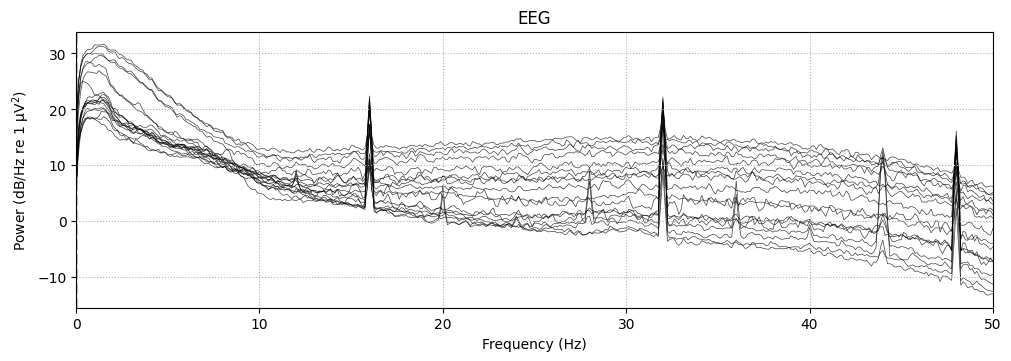

In [16]:
# This resets matplotlib to the standard white-background scientific style
plt.style.use('default')

# Generate the plot
fig_psd = raw.compute_psd(fmax=50).plot(
    average=False,
    spatial_colors=True,
    show=False
)

# Option 2: The "Manual" Fix (If Option 1 doesn't work)
# Explicitly paint the background white and text black
fig_psd.patch.set_facecolor('white') # Outer background

for ax in fig_psd.axes:
    ax.set_facecolor('white')        # Inner plot background

    # Set text and lines to black for visibility
    ax.xaxis.label.set_color('black')
    ax.yaxis.label.set_color('black')
    ax.title.set_color('black')
    ax.tick_params(axis='x', colors='black')
    ax.tick_params(axis='y', colors='black')

    # Make borders black
    for spine in ax.spines.values():
        spine.set_edgecolor('black')

# Finally show the plot
plt.show()

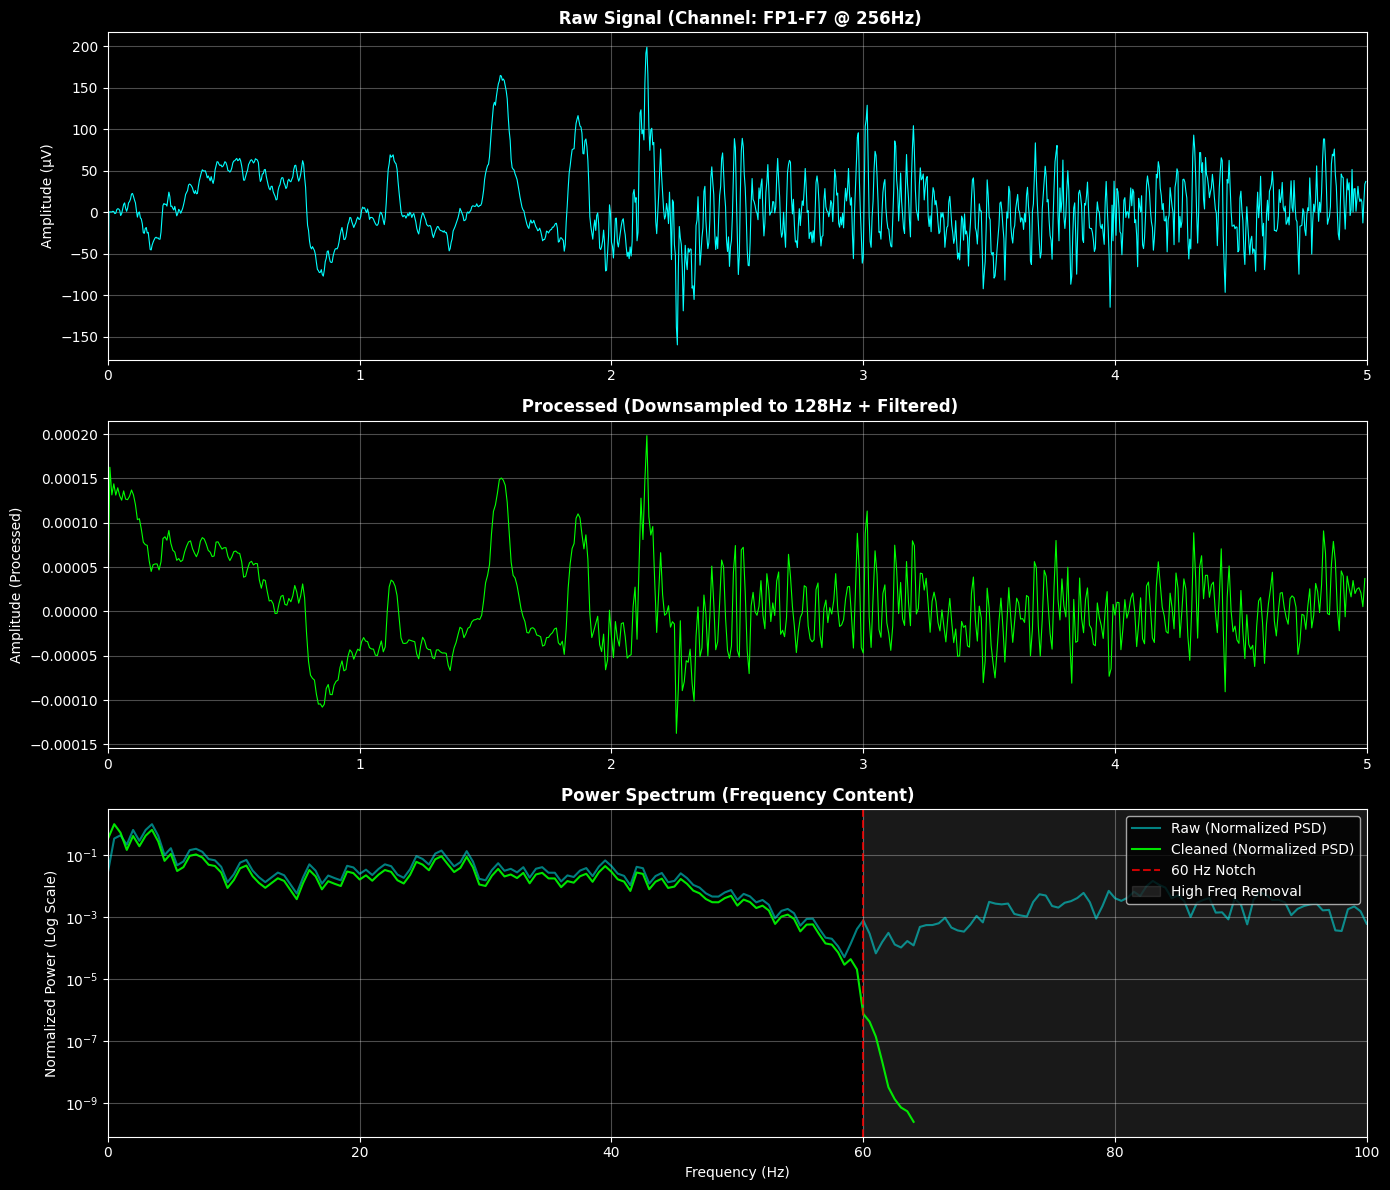

In [17]:
# Suppress warnings for cleaner output
from scipy.signal import welch
import warnings
warnings.filterwarnings("ignore")

# ============================================
# 1. SETUP & LOADING
# ============================================
dataset_path = 'data-understanding/data/chb-mit'
subject_folders = deniz.get_folder_names(dataset_path)

FINAL_CHANNELS = [
    'FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1',
    'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1',
    'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2',
    'FP2-F8', 'F8-T8', 'T8-P8', 'P8-O2',
    'FZ-CZ', 'CZ-PZ'
]

# Ensure we have data to load
if not subject_folders:
    raise FileNotFoundError(f"No subject folders found in {dataset_path}")

# Get paths for the first subject
edf_paths = deniz.get_edf_paths(dataset_path, subject_folders[0])
file_path = edf_paths[0]
print(f" Loading data from: {file_path}")

# 1. Load using your utility
# Note: Ensure this matches the function name in your my_utils.py
raw = deniz.fix_eeg_channels(file_path, FINAL_CHANNELS)

# 2. Extract info before processing
original_fs = int(raw.info['sfreq'])
print(f"   Original Sampling Rate: {original_fs} Hz")

# Select a specific channel to visualize
channel_name = FINAL_CHANNELS[0]
channel_idx = raw.ch_names.index(channel_name)

# Get 5 seconds of RAW data (converted to µV for readability)
duration_sec = 5
raw_samples = int(duration_sec * original_fs)
raw_signal = raw.get_data(picks=[channel_idx], stop=raw_samples)[0] * 1e6

# ============================================
# 2. DEFINE PREPROCESSING LOGIC
# ============================================

def get_processed_segment(raw_obj, channel_idx, duration_sec):
    # Create a copy to avoid modifying the original 'raw' object
    raw_copy = raw_obj.copy()

    # 1. Downsample
    raw_copy = deniz.downsample(raw_copy)
    new_fs = int(raw_copy.info['sfreq'])

    # 2. Apply Filtering (Bandpass + Notch)
    raw_copy = deniz.apply_filtering(raw_copy)

    # 3. Extract Data
    n_samples = int(duration_sec * new_fs)
    data = raw_copy.get_data(picks=[channel_idx], stop=n_samples)[0]

    return data, new_fs

# Get the processed version
clean_signal, new_fs = get_processed_segment(raw, channel_idx, duration_sec)

# ============================================
# 3. VISUALIZATION
# ============================================

print("="*60)
print(" VISUALIZING PREPROCESSING EFFECT")
print("="*60)

# Time vectors
time_raw = np.arange(len(raw_signal)) / original_fs
time_clean = np.arange(len(clean_signal)) / new_fs

# Apply Dark Background Style
plt.style.use('dark_background')

# Create figure
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Plot 1: Raw Signal
# Using 'cyan' for better visibility on black background
axes[0].plot(time_raw, raw_signal, color='cyan', linewidth=0.8)
axes[0].set_title(f' Raw Signal (Channel: {channel_name} @ {original_fs}Hz)', fontweight='bold')
axes[0].set_ylabel('Amplitude (μV)')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, duration_sec)

# Plot 2: Cleaned Signal
# Using 'lime' (bright green) for contrast
axes[1].plot(time_clean, clean_signal, color='lime', linewidth=0.8)
axes[1].set_title(f' Processed (Downsampled to {new_fs}Hz + Filtered)', fontweight='bold')
axes[1].set_ylabel('Amplitude (Processed)')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, duration_sec)

# Plot 3: Power Spectrum Comparison
freqs_raw, psd_raw = welch(raw_signal, fs=original_fs, nperseg=original_fs*2)
freqs_clean, psd_clean = welch(clean_signal, fs=new_fs, nperseg=new_fs*2)

# Normalize PSD for visual comparison
psd_raw_norm = psd_raw / np.max(psd_raw)
psd_clean_norm = psd_clean / np.max(psd_clean)

axes[2].semilogy(freqs_raw, psd_raw_norm, color='cyan', alpha=0.5, label='Raw (Normalized PSD)', linewidth=1.5)
axes[2].semilogy(freqs_clean, psd_clean_norm, color='lime', alpha=0.9, label='Cleaned (Normalized PSD)', linewidth=1.5)

# Markers for Filter Effects
axes[2].axvline(x=60, color='red', linestyle='--', alpha=0.8, label='60 Hz Notch')
axes[2].axvspan(60, 128, color='white', alpha=0.1, label='High Freq Removal')

axes[2].set_title('Power Spectrum (Frequency Content)', fontweight='bold')
axes[2].set_xlabel('Frequency (Hz)')
axes[2].set_ylabel('Normalized Power (Log Scale)')
axes[2].set_xlim(0, 100)
axes[2].legend(loc='upper right')
axes[2].grid(True, alpha=0.3, which='both')

plt.tight_layout()

plt.savefig(output_file, dpi=150, bbox_inches='tight')
plt.show(block=True)

print("\n Preprocessing Effects Observed:")
print(f"   ✓ Sampling Rate: {original_fs}Hz -> {new_fs}Hz")
print("   ✓ High-frequency noise (>60Hz) reduced")
print("   ✓ 60 Hz power line peak removed")

print("\n" + "="*60)
print(" Visualization complete!")
print("="*60)

In [18]:
# Final label verification
import numpy as np
path = "dataset_final/train/chb08/chb08_02_train.npz"
npz = np.load(path)
npz['X']
np.count_nonzero(npz['y'])

115

In [19]:
npz['y']


array([0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 0, 1], dtype=int8)

In [20]:
np.count_nonzero(npz['y'])


115

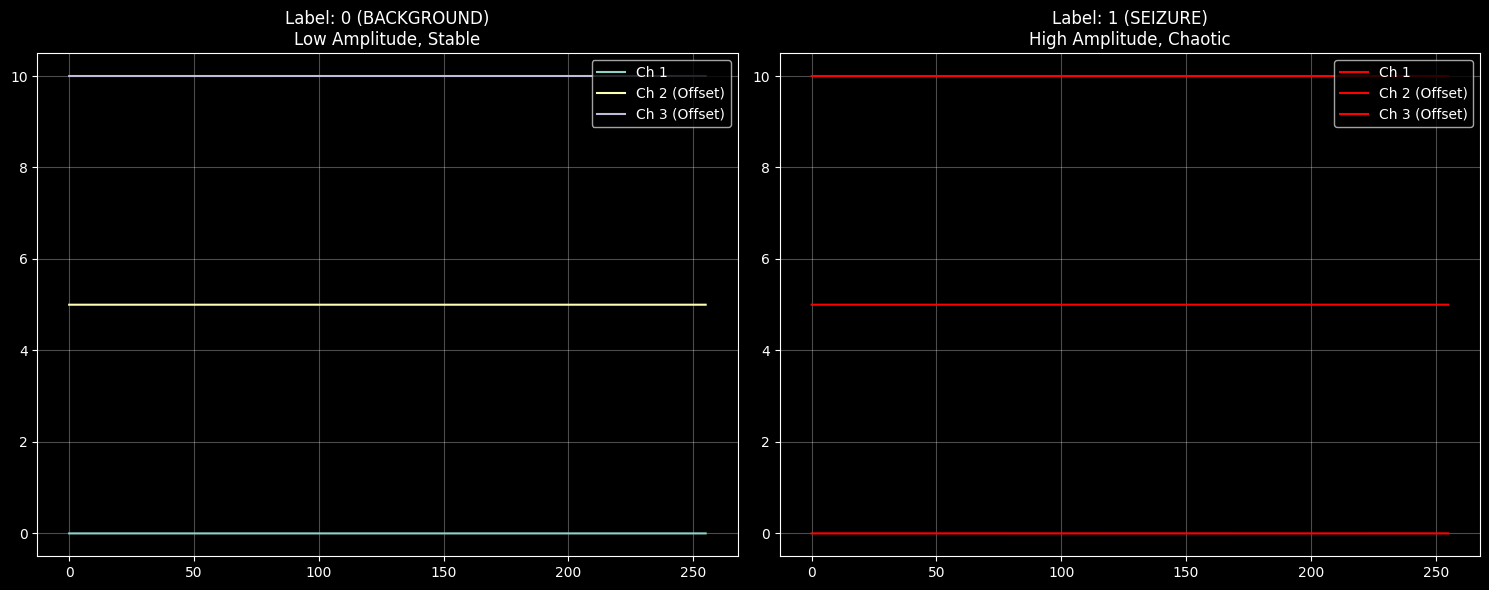

In [21]:
# Load your processed file
data = np.load("dataset_final/train/chb01/chb01_03_train.npz")
X = npz['X']  # Shape: (N, 18, 256)
y = npz['y']  # Shape: (N,)

# Get indices for each class
seizure_idxs = np.where(y == 1)[0]
normal_idxs = np.where(y == 0)[0]

print(f"Total Seizures: {len(seizure_idxs)}")
print(f"Total Background: {len(normal_idxs)}")

# --- PLOT VALIDATION ---
plt.figure(figsize=(15, 6))

# Plot Background (Label 0)
plt.subplot(1, 2, 1)
if len(normal_idxs) > 0:
    idx = normal_idxs[0]
    # Plot first 3 channels
    plt.plot(X[idx, 0, :], label='Ch 1')
    plt.plot(X[idx, 1, :] + 5, label='Ch 2 (Offset)')
    plt.plot(X[idx, 2, :] + 10, label='Ch 3 (Offset)')
    plt.title(f"Label: 0 (BACKGROUND)\nLow Amplitude, Stable")
    plt.legend()
    plt.grid(True, alpha=0.3)

# Plot Seizure (Label 1)
plt.subplot(1, 2, 2)
if len(seizure_idxs) > 0:
    idx = seizure_idxs[0]
    # Plot first 3 channels
    plt.plot(X[idx, 0, :], label='Ch 1', color='red')
    plt.plot(X[idx, 1, :] + 5, label='Ch 2 (Offset)', color='red')
    plt.plot(X[idx, 2, :] + 10, label='Ch 3 (Offset)', color='red')
    plt.title(f"Label: 1 (SEIZURE)\nHigh Amplitude, Chaotic")
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
data = np.load("dataset_final/train/chb03/chb03_03_train.npz")


In [24]:
import numpy as np
import mne

# Veriyi yükle
data_npz = np.load("dataset_final/train/chb08/chb08_02_train.npz")

# Dosya içindeki dizileri kontrol et (Genelde 'data' ve 'labels' olur)
print(f"Dosya içeriği: {data_npz.files}")

signals = data_npz['X']  # Şekli genellikle (Kanallar, Zaman) veya (Zaman, Kanallar)
labels = data_npz['y'] # Nöbet anlarını belirten dizi

Dosya içeriği: ['X', 'y', 'subject', 'file_name']


In [25]:
labels

array([0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 0, 1], dtype=int8)

In [26]:
np.count_nonzero(npz['y'])


115

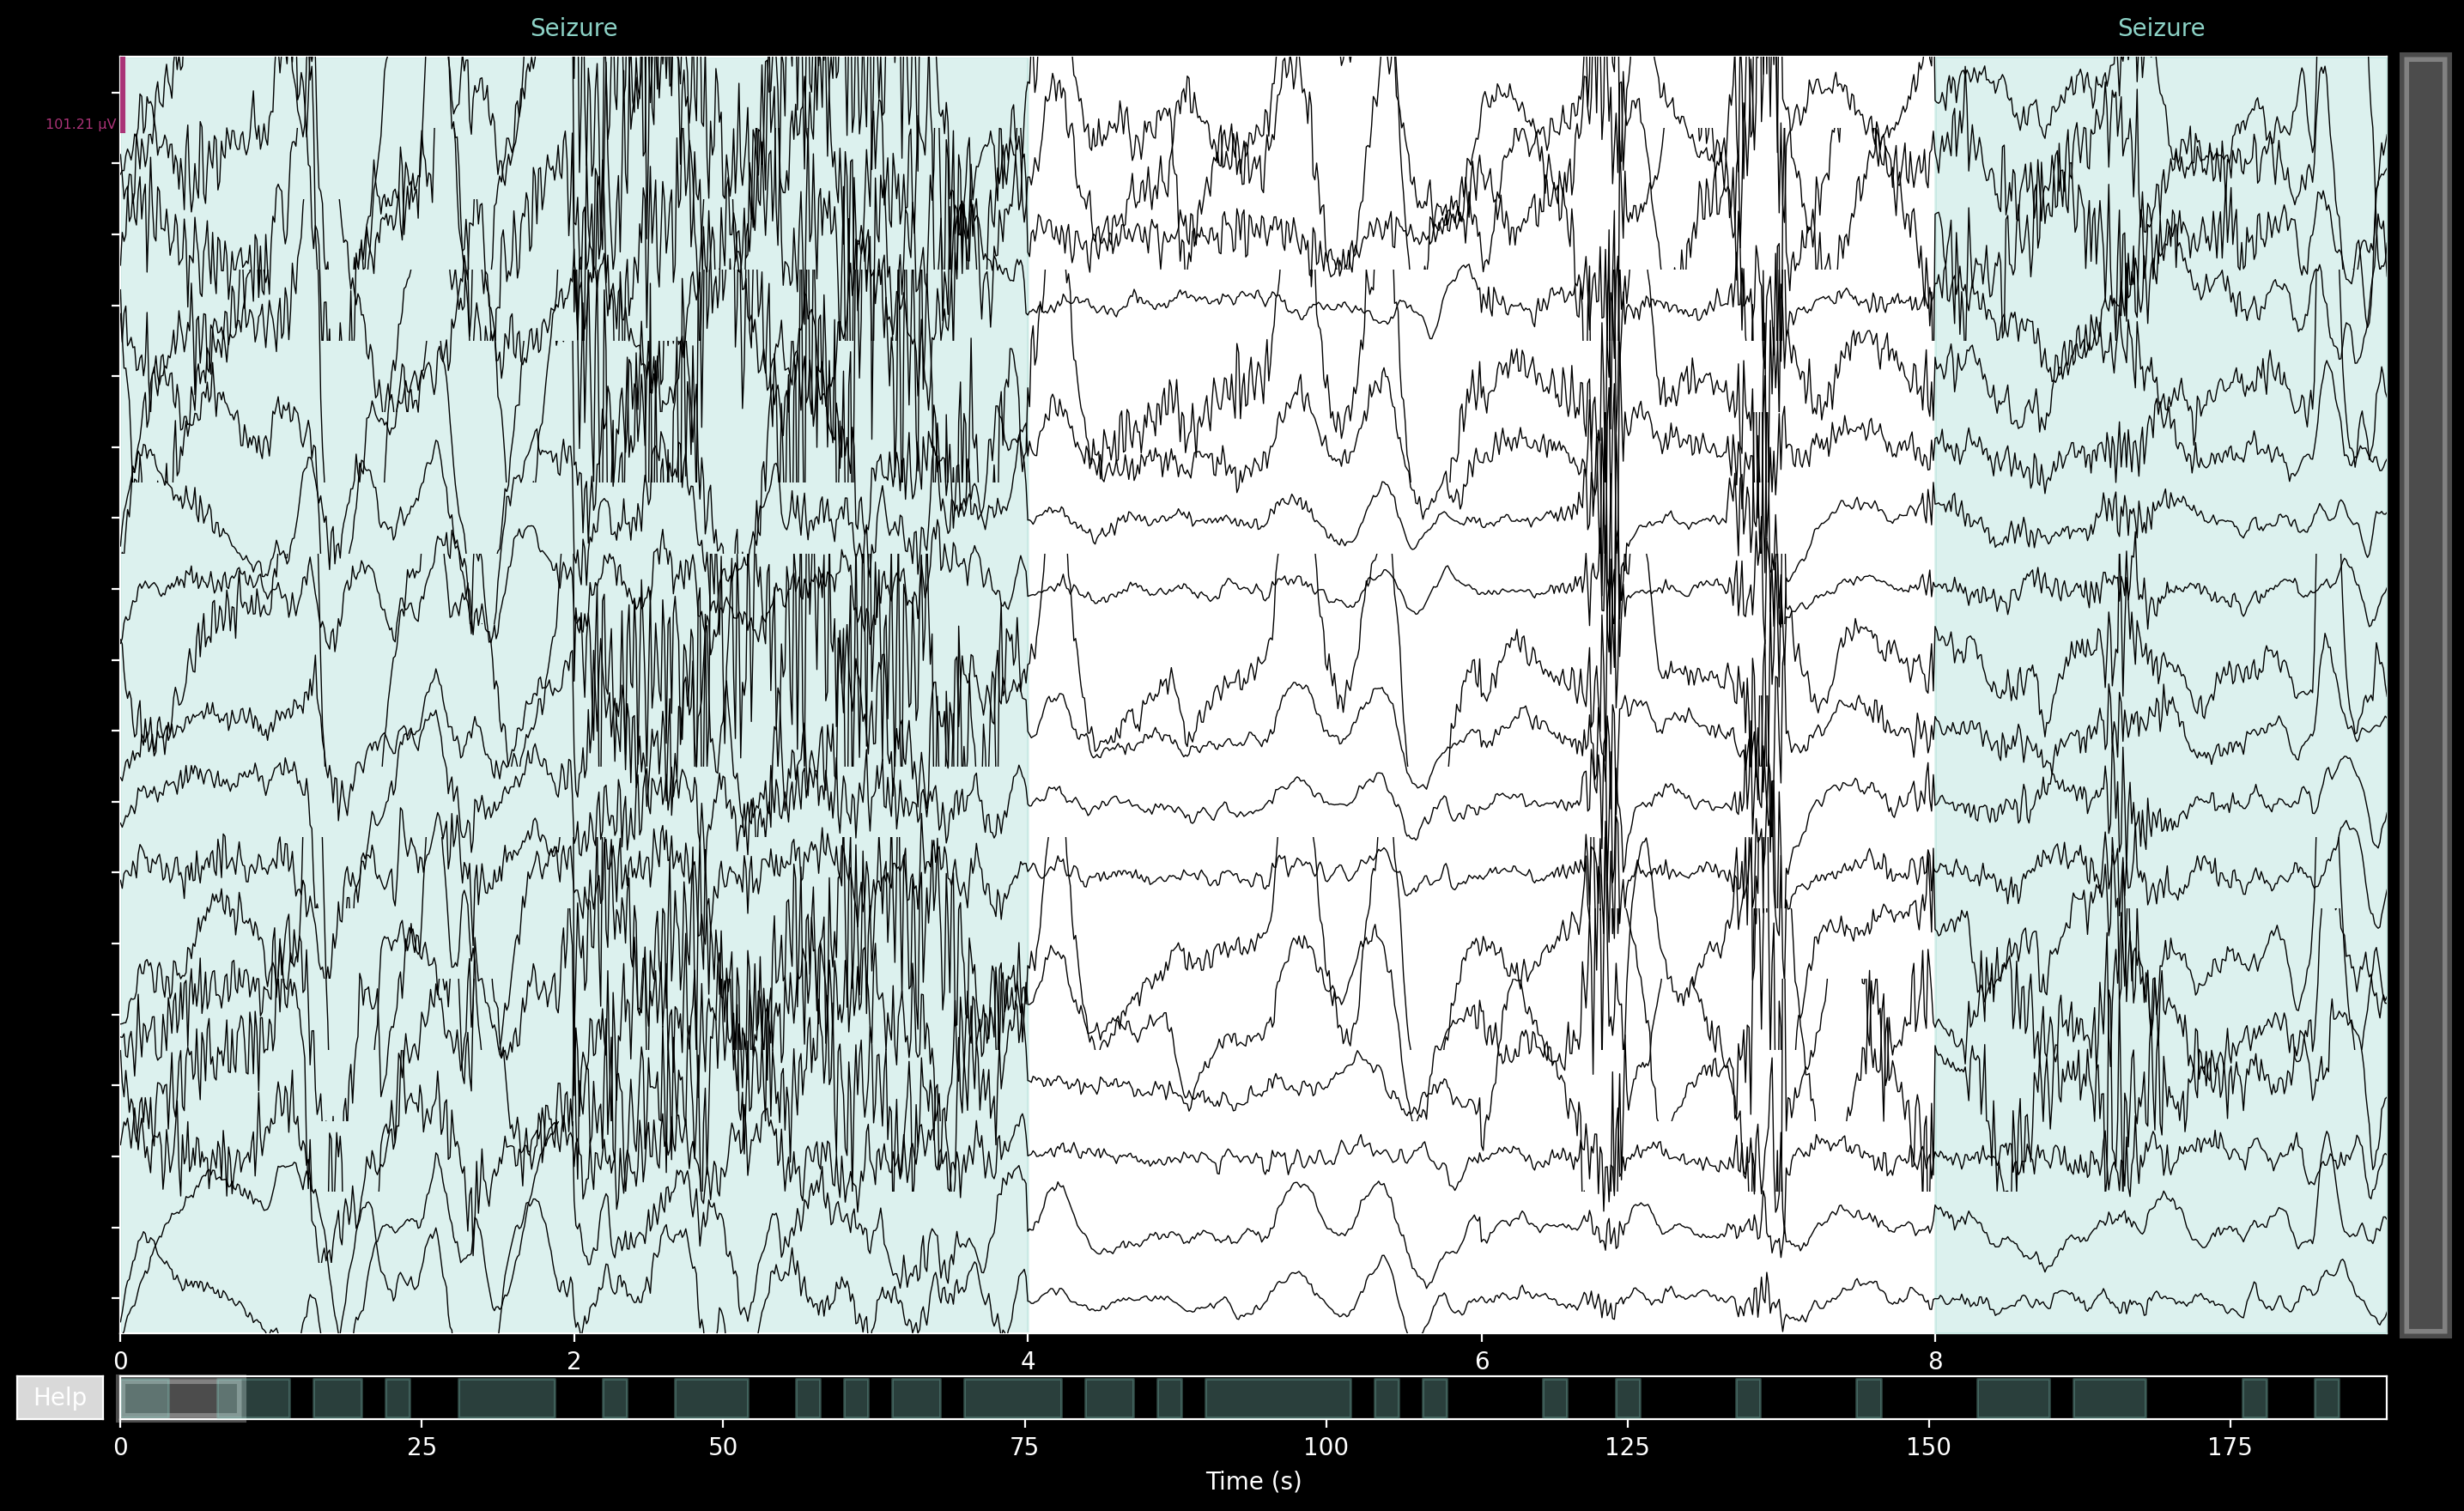

In [27]:
import numpy as np
import mne
import matplotlib
matplotlib.use('TkAgg')

# 1. Veriyi yükle
data_npz = np.load("dataset_final/train/chb03/chb03_03_train.npz")
signals = data_npz['X']   # Şekli: (54, 18, 256)
labels = data_npz['y'] # Şekli muhtemelen: (54,) veya (54, 256)

# 2. Veriyi uç uca ekleyerek yeniden şekillendir (Reshape)
# (Epochs, Channels, Times) -> (Channels, Epochs * Times)
n_epochs, n_channels, n_times = signals.shape
signals_reshaped = signals.transpose(1, 0, 2).reshape(n_channels, -1)

# 3. MNE Bilgi Nesnesini Oluştur
sfreq = 128
ch_names = [f"EEG {i}" for i in range(n_channels)]
info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types='eeg')

# 4. Raw Nesnesini Oluştur
raw = mne.io.RawArray(signals_reshaped, info)

# 5. Etiketleri (Anotasyonları) Hazırla
# Her pencerenin bir etiketi varsa, her birini n_times kadar tekrar etmeliyiz
full_labels = np.repeat(labels, n_times)

# Geçişleri bul ve anotasyon oluştur
diff = np.diff(full_labels, prepend=0)
onsets = np.where(diff > 0)[0] / sfreq
offsets = np.where(diff < 0)[0] / sfreq

# Eğer son pencere nöbetle bitiyorsa offset ekleyelim
if len(offsets) < len(onsets):
    offsets = np.append(offsets, signals_reshaped.shape[1] / sfreq)

durations = offsets - onsets
annot = mne.Annotations(onset=onsets, duration=durations, description=['Seizure']*len(onsets))
raw.set_annotations(annot)

# 6. Görselleştir
raw.plot(scalings='auto', block=True)

In [28]:
labels

array([1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0], dtype=int8)

In [29]:
np.count_nonzero(npz['y'])


115